In [3]:
# --- KEPLER --- Homework9
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [4]:
df = pd.read_csv("solar_system.csv")
df = df.set_index(["Attribute"])
df

,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
Attribute,,,,,,,,,,
Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3
Rotation Period (hours),1407.6,-5832.5,23.9,655.7,24.6,9.9,10.7,-17.2,16.1,-153.3
Length of Day (hours),4222.6,2802.0,24.0,708.7,24.7,9.9,10.7,17.2,16.1,153.3
Distance from Sun (10^6 km),57.9,108.2,149.6,0.384,228.0,778.5,1432.0,2867.0,4515.0,5906.4
Perihelion (10^6 km),46.0,107.5,147.1,0.363,206.7,740.6,1357.6,2732.7,4471.1,4436.8


In [5]:
df.shape  #20 rows by 11 columns

(20, 10)

In [6]:
df.head()

,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
Attribute,,,,,,,,,,
Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3


In [7]:
df.tail()

,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
Attribute,,,,,,,,,,
Mean Temperature (C),167,464,15,-20,-65,-110,-140,-195,-200,-225
Surface Pressure (bars),0,92,1,0,0.01,Unknown,Unknown,Unknown,Unknown,0.00001
Number of Moons,0,0,1,0,2,95,274,28,16,5
Ring System?,No,No,No,No,No,Yes,Yes,Yes,Yes,No
Global Magnetic Field?,Yes,No,Yes,No,No,Yes,Yes,Yes,Yes,Unknown


In [8]:
print(df.columns)

Index(['Mercury', 'Venus', 'Earth', 'Moon', 'Mars', 'Jupiter', 'Saturn',
       'Uranus', 'Neptune', 'Pluto'],
      dtype='object')


In [9]:
print(df['Attribute'])

KeyError: 'Attribute'

In [10]:
orbital_period =df.iloc[10].astype(float)
perihelion = df.iloc[8].astype(float)
aphelion = df.iloc[9].astype(float)

In [11]:
# Perihelion is the closest point to the object being orbited along a planet's orbital path.
# Aphelion is the furthest point to the object being orbited along a planet's orbital path.
# The semi-major axis is the radius of the longest diameter in the orbital path.

In [12]:
semimajor = (perihelion + aphelion)/2
print(semimajor)

Mercury      57.9000
Venus       108.2000
Earth       149.6000
Moon          0.3845
Mars        228.0000
Jupiter     778.5000
Saturn     1432.0500
Uranus     2867.0500
Neptune    4515.0000
Pluto      5906.3500
dtype: float64


In [13]:
df = pd.read_csv("solar_system.csv")
df = df.set_index(["Attribute"])
df

,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
Attribute,,,,,,,,,,
Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3
Rotation Period (hours),1407.6,-5832.5,23.9,655.7,24.6,9.9,10.7,-17.2,16.1,-153.3
Length of Day (hours),4222.6,2802.0,24.0,708.7,24.7,9.9,10.7,17.2,16.1,153.3
Distance from Sun (10^6 km),57.9,108.2,149.6,0.384,228.0,778.5,1432.0,2867.0,4515.0,5906.4
Perihelion (10^6 km),46.0,107.5,147.1,0.363,206.7,740.6,1357.6,2732.7,4471.1,4436.8


In [22]:
new_row = pd.Series(semimajor)
df.loc[len(df)] = new_row
df = df.rename({20: "Semi-major Axis (10^6 km)"})
df = df.drop([23,25])
df

,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
Attribute,,,,,,,,,,
Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3
Rotation Period (hours),1407.6,-5832.5,23.9,655.7,24.6,9.9,10.7,-17.2,16.1,-153.3
Length of Day (hours),4222.6,2802.0,24.0,708.7,24.7,9.9,10.7,17.2,16.1,153.3
Distance from Sun (10^6 km),57.9,108.2,149.6,0.384,228.0,778.5,1432.0,2867.0,4515.0,5906.4
Perihelion (10^6 km),46.0,107.5,147.1,0.363,206.7,740.6,1357.6,2732.7,4471.1,4436.8


In [23]:
df.shape # 21 rows, 10 columns

(21, 10)

<function matplotlib.pyplot.show(close=None, block=None)>

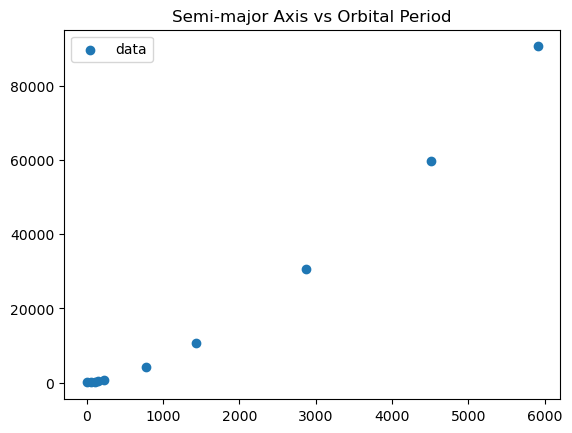

In [24]:
orbital_period =df.iloc[10].astype(float)
semi_major_axis =df.iloc[20].astype(float)

plt.figure()
x = semi_major_axis
y = orbital_period
plt.scatter(x, y, label = 'data')
plt.title("Semi-major Axis vs Orbital Period")
plt.xlabel = "Semi-major Axis (10^6 km)"
plt.ylabel = "Orbital Period (days)"
plt.legend()
plt.show

In [29]:
def keplers_third_law(a, m):
    return m*a**1.5

In [74]:
popt, pcov = curve_fit(keplers_third_law, x, y)
m_fit = popt
print(f" Kepler's Third Law: m_fit = {m_fit[0]:.2f}")

 Kepler's Third Law: m_fit = 0.20


In [77]:
residuals = y - keplers_third_law(x, m_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_squared = chi2/dof

<function matplotlib.pyplot.show(close=None, block=None)>

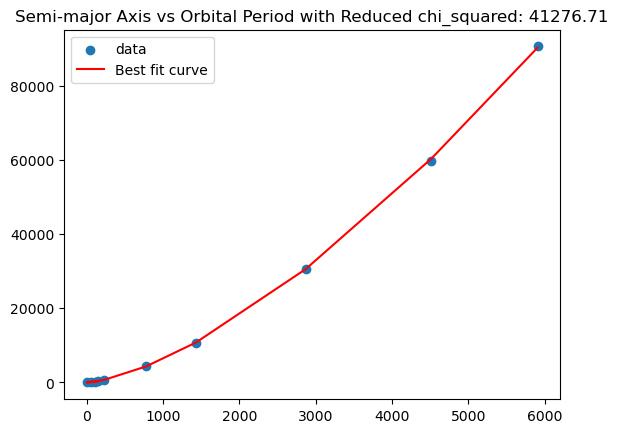

In [78]:
plt.figure()
x = semi_major_axis
y = orbital_period
plt.scatter(x, y, label = 'data')
plt.title(f"Semi-major Axis vs Orbital Period with Reduced chi_squared: {chi2_squared:.2f}")
plt.xlabel = "Semi-major Axis (10^6 km)"
plt.ylabel = "Orbital Period (days)"

#best fit curve
plt.plot(x, keplers_third_law(x, m_fit), color = 'red', label='Best fit curve')
plt.legend()
plt.show

In [80]:
df.to_csv("kepler.csv", index=False)